In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.cluster import KMeans

In [2]:
data = pd.read_csv(r'D:\MachineLearning\MachineLearning_Intro\the-data-science-bootcamp\Section 38 K-Means\Countryclusters.csv')

In [3]:
data

,Country,Latitude,Longitude,Language
0,USA,44.97,-103.77,English
1,Canada,62.40,-96.80,English
2,France,46.75,2.40,French
3,UK,54.01,-2.53,English
4,Germany,51.15,10.40,German
5,Australia,-25.45,133.11,English


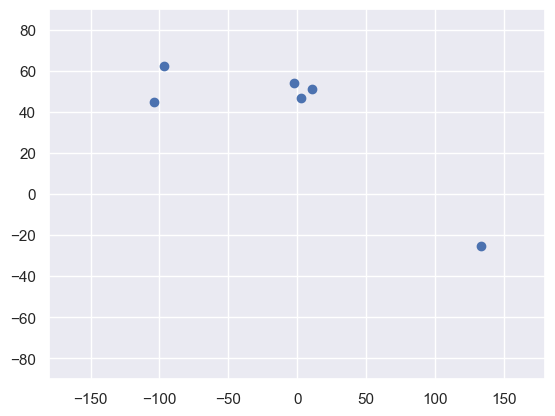

In [4]:
plt.scatter(data['Longitude'],data['Latitude'])
plt.xlim(-180,180)
plt.ylim(-90,90)
plt.show()

# Select the feature

In [5]:
x=data.iloc[:,1:3]

In [6]:
x

,Latitude,Longitude
0,44.97,-103.77
1,62.40,-96.80
2,46.75,2.40
3,54.01,-2.53
4,51.15,10.40
5,-25.45,133.11


# Clustering

In [7]:
kmeans=KMeans(2)
#Change it to 3 if you want 3 cluster

In [8]:
kmeans.fit(x)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


# Clustering results

In [9]:
identified_clusters=kmeans.fit_predict(x)
identified_clusters

array([0, 0, 0, 0, 0, 1], dtype=int32)

In [10]:
data_with_clusters=data.copy()
data_with_clusters['Cluster']=identified_clusters
data_with_clusters

,Country,Latitude,Longitude,Language,Cluster
0,USA,44.97,-103.77,English,0
1,Canada,62.40,-96.80,English,0
2,France,46.75,2.40,French,0
3,UK,54.01,-2.53,English,0
4,Germany,51.15,10.40,German,0
5,Australia,-25.45,133.11,English,1


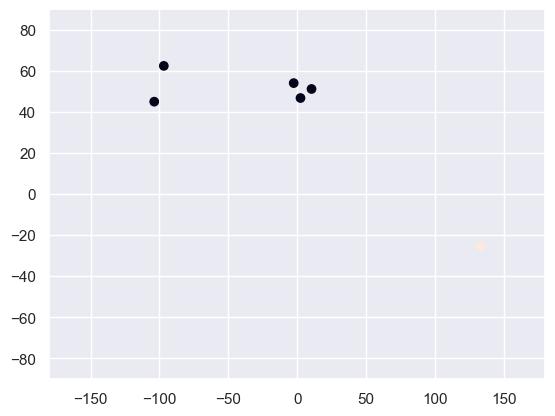

In [11]:
plt.scatter(data_with_clusters['Longitude'],data_with_clusters['Latitude'],c=data_with_clusters['Cluster'])
plt.xlim(-180,180)
plt.ylim(-90,90)
plt.show()

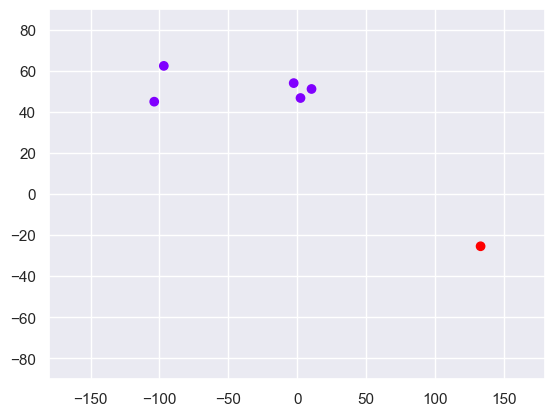

In [12]:
plt.scatter(data_with_clusters['Longitude'],data_with_clusters['Latitude'],c=data_with_clusters['Cluster'],cmap='rainbow')
plt.xlim(-180,180)
plt.ylim(-90,90)
plt.show()

## Clustering Categorical Data

In [13]:
data = pd.read_csv(r'D:\MachineLearning\MachineLearning_Intro\the-data-science-bootcamp\Section 38 K-Means\Countryclusters.csv')

In [14]:
data

,Country,Latitude,Longitude,Language
0,USA,44.97,-103.77,English
1,Canada,62.40,-96.80,English
2,France,46.75,2.40,French
3,UK,54.01,-2.53,English
4,Germany,51.15,10.40,German
5,Australia,-25.45,133.11,English


## Map the data

In [15]:
data_mapped=data.copy()

In [16]:
data_mapped['Language']=data_mapped['Language'].map({'English':0,'French':1,'German':2})

In [17]:
data_mapped

,Country,Latitude,Longitude,Language
0,USA,44.97,-103.77,0
1,Canada,62.40,-96.80,0
2,France,46.75,2.40,1
3,UK,54.01,-2.53,0
4,Germany,51.15,10.40,2
5,Australia,-25.45,133.11,0


## Select the features

In [18]:
x=data_mapped.iloc[:,3:4]

In [19]:
x

,Language
0,0
1,0
2,1
3,0
4,2
5,0


## Clustering

In [20]:
kmeans=KMeans(3)

In [21]:
kmeans.fit(x)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


# Clustering Result

In [22]:
identified_clusters=kmeans.fit_predict(x)
identified_clusters

array([0, 0, 1, 0, 2, 0], dtype=int32)

In [23]:
data_with_clusters=data_mapped.copy()
data_with_clusters['Cluster']=identified_clusters
data_with_clusters

,Country,Latitude,Longitude,Language,Cluster
0,USA,44.97,-103.77,0,0
1,Canada,62.40,-96.80,0,0
2,France,46.75,2.40,1,1
3,UK,54.01,-2.53,0,0
4,Germany,51.15,10.40,2,2
5,Australia,-25.45,133.11,0,0


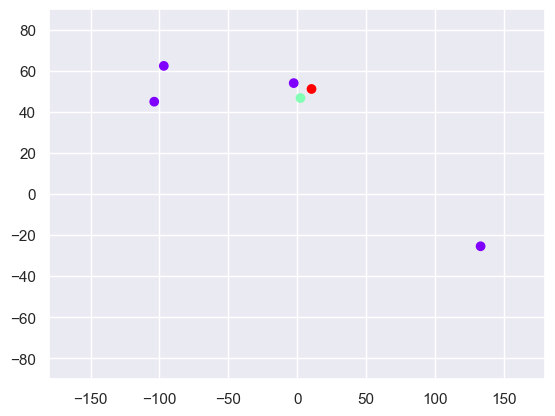

In [24]:
plt.scatter(data_with_clusters['Longitude'],data_with_clusters['Latitude'],c=data_with_clusters['Cluster']
            ,cmap='rainbow')
plt.xlim(-180,180)
plt.ylim(-90,90)
plt.show()

## How to choose the number of clusters

In [25]:
#Minimize the distance between points in a cluster
# Maximize the distance between cluster
# WCSS within-cluster sum of squares

# If we minimize WCSS, we have reached the perfect clustering solution


# WCSS

In [26]:
kmeans.inertia_

0.0